# Import libraries and settings

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from open_ephys.analysis import Session
import spike_detection.spike_detection_utils as sdu

from decay_model.modules.spike_localization import SpikeLocalizationVAE, SpikeLocalizationLossFunc
from decay_model.data.spike_dataset import SpikeDataset
from decay_model.utilities import load_channel_positions_from_xml, pad_channel_positions

%load_ext autoreload
%autoreload 2
%matplotlib inline
%connect_info

{"key":"04c89fdb-711a-4055-b543-6a02d07210fa","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9000,"control_port":9001,"shell_port":9002,"stdin_port":9003,"iopub_port":9004,"kernel_name":"python3123jvsc74a57bd085e2832fdd293665819b49683af0bdc6e791309ff8fe3c202b4db75f6510d827"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing /run/user/1000/jupyter/runtime/kernel-v3142b359b7a67124804cc3b434a722e89ee4f8342.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


# Define variables used throughout

In [2]:
recording_name = "EJT178_implant1_recording6_29-03-2022"
save_directory = '../data/'

spike_jitter = 5
amp_jitter = 10
save = True
n_spikes = 1_000
batch_size = 50

np.random.seed(0)
torch.manual_seed(0)

if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

# Load channel positions

In [3]:
channel_positions = load_channel_positions_from_xml("/ceph/sjones/projects/sequence_squad/data/raw_neuropixel/OE_DATA/EJT178/290322/2022-03-29_13-55-06/Record Node 103/settings.xml", device=device)

# Load spiking data

In [4]:
multiunits_df = pd.read_csv("/ceph/sjones/projects/sequence_squad/organised_data/animals/EJT178_implant1/recording6_29-03-2022/ephys/non_curated_spikes/multiunits_df.csv", index_col=0)
good_units_df = pd.read_csv("/ceph/sjones/projects/sequence_squad/organised_data/animals/EJT178_implant1/recording6_29-03-2022/ephys/non_curated_spikes/good_units_df.csv", index_col=0)
sorted_units_df = pd.concat([multiunits_df, good_units_df], axis=0, ignore_index=True).sort_values(by="cluster_id").reset_index()
sorted_units_df

,index,cluster_id,cluster_depth,Spike_times,Region
0,250,0,53.939234,"[0.11356666666666666, 0.14203333333333334, 0.1...",striatum
1,251,1,29.309727,"[1.3731666666666666, 6.086033333333333, 6.1114...",striatum
2,0,2,43.224752,"[1.1418, 11.8113, 11.8445, 11.853366666666666,...",striatum
3,252,3,50.218501,"[0.041633333333333335, 0.119, 0.51986666666666...",striatum
4,253,4,67.263795,"[0.7954333333333333, 0.9412666666666667, 0.995...",striatum
...,...,...,...,...,...
559,246,630,3744.164978,"[0.0217, 0.656, 1.1975333333333333, 3.3758, 3....",m_cortex
560,247,631,3799.370537,"[711.4178333333333, 1912.4845, 2162.1569666666...",m_cortex
561,248,632,3781.873730,"[31.368566666666666, 48.328066666666665, 48.56...",m_cortex
562,563,633,3799.758416,"[1.8550333333333333, 8.547933333333333, 8.5801...",m_cortex


# Load raw ephys data

In [5]:
session_data = Session("/ceph/sjones/projects/sequence_squad/data/raw_neuropixel/OE_DATA/EJT178/290322/2022-03-29_13-55-06/")

recording = session_data.recordnodes[0].recordings[0]
recording.add_sync_line(1, 102, "0", main=True)
recording.add_sync_line(1, 109, "1", main=False)
recording.add_sync_line(1, 109, "0", main=False)

recording.compute_global_timestamps()

ephys_data = recording.continuous[0].samples
ephys_times = recording.continuous[0].global_timestamps
ephys_times -= ephys_times[0]

fs = recording.continuous[0].metadata['sample_rate']

means_ephys_data = torch.mean(torch.tensor(ephys_data[:1000], dtype=torch.float32), dim=0)
idx_to_rm = torch.where(torch.abs(means_ephys_data - torch.mean(means_ephys_data)) > torch.std(means_ephys_data) * 3)[0]
ephys_mask = ~torch.isin(torch.arange(ephys_data.shape[1]), idx_to_rm)

Processor ID: 102, Stream Name: 0, Line: 1 (main sync line))
  First event sample number: 60177759
  Last event sample number: 467680808
  Total sync events: 13583
  Sample rate: 30000
Processor ID: 109, Stream Name: 1, Line: 1 (aux sync line))
  First event sample number: 5013094
  Last event sample number: 38968312
  Total sync events: 13583
  Scale factor: 12.00119077427216
  Actual sample rate: 2499.751946641263
Processor ID: 109, Stream Name: 0, Line: 1 (aux sync line))
  First event sample number: 60157124
  Last event sample number: 467619739
  Total sync events: 13583
  Scale factor: 1.000099233643803
  Actual sample rate: 29997.023286076077


# Load spike times

In [6]:
all_spike_times = sorted_units_df["Spike_times"].map(lambda s: np.fromstring(s[1:-1], sep=","))

spike_times = np.round(np.concatenate(all_spike_times.values) * fs).astype(np.int32)

spike_ids = np.repeat(sorted_units_df["cluster_id"].values.astype(np.int32), all_spike_times.map(len).values)

sorted_indices = np.argsort(spike_times)
spike_times = spike_times[sorted_indices]
spike_ids = spike_ids[sorted_indices]

if n_spikes is not None:
    spike_times = spike_times[:n_spikes]
    spike_ids = spike_ids[:n_spikes]

# Prepare channels with padding

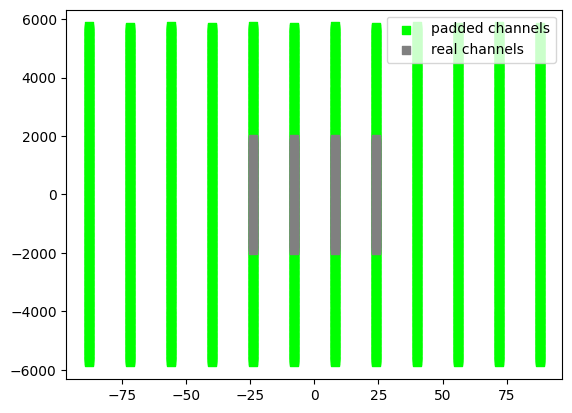

In [7]:
padded_channel_positions = pad_channel_positions(channel_positions)

plt.scatter(padded_channel_positions[:,1].cpu().numpy(), padded_channel_positions[:,2].cpu().numpy(), color='lime', marker='s', alpha=1.0, label='padded channels')
plt.scatter(channel_positions[:,1].cpu().numpy(), channel_positions[:,2].cpu().numpy(), color='grey', marker='s', alpha=1.0, label='real channels')
plt.legend()

# Prepare spikes for training

In [ ]:
spike_window = 60
half_window = spike_window // 2
n_channels = channel_positions.shape[0]
n_spikes = len(spike_ids)
n_neighbors = 13
n_events = n_spikes * n_neighbors

padded_candidate_channels = sdu.build_neighbors(padded_channel_positions.cpu().numpy(), k_nearest = n_neighbors, include_self=True)
car_neighbors = sdu.build_neighbors(channel_positions.cpu().numpy(), radius=100)
candidate_channels = sdu.build_neighbors(channel_positions.cpu().numpy(), radius=40, include_self=True)

amps_tensor = torch.zeros((n_events, n_neighbors, 2), device=device, dtype=torch.float32)
channel_locations_tensor = torch.zeros((n_events, n_neighbors, 3), device=device, dtype=torch.float32)
local_waveforms_tensor = torch.zeros((n_events, n_neighbors, spike_window), device=device, dtype=torch.float32)
center_locations_tensor = torch.zeros((n_events, 3), device=device, dtype=torch.float32)

central_channel_tensor = torch.zeros(n_events, device=device, dtype=torch.int32)
spike_time_tensor = torch.zeros(n_events, device=device, dtype=torch.int32)
spike_idx_tensor = torch.zeros(n_events, device=device, dtype=torch.int32)
spike_cluster_id_tensor = torch.zeros(n_events, device=device, dtype=torch.int32)

filtered_ephys_data_start = None

event_idx = 0

for spike_i, (spike_id, spike_time) in enumerate(zip(spike_ids, spike_times)):

    if (spike_i + 1) % (n_spikes // 10) == 0:
        print(f"Processing: {(spike_i + 1) / n_spikes:.1%}", end="\r")

    if filtered_ephys_data_start is None:
        start = max(0, spike_time - 1 * fs)
        end = min(ephys_data.shape[0], spike_time + 5 * fs)

        x_bp = sdu.bandpass_filter(ephys_data[start:end, ephys_mask], fs=fs)
        x_car = sdu.local_median_car(x_bp, car_neighbors)
        x_scaled = sdu.scale_channels_mad(x_car)
        x_scaled = torch.tensor(x_scaled, device=device, dtype=torch.float32)

        filtered_ephys_data_start = start

    elif spike_time >= filtered_ephys_data_start + 5 * fs:
        start = np.max([0, spike_time - 1 * fs])
        end = np.min([ephys_data.shape[0], spike_time + 5 * fs])

        x_bp = sdu.bandpass_filter(ephys_data[start:end, ephys_mask], fs=fs)
        x_car = sdu.local_median_car(x_bp, car_neighbors)
        x_scaled = sdu.scale_channels_mad(x_car)
        x_scaled = torch.tensor(x_scaled, device=device, dtype=torch.float32)

        filtered_ephys_data_start = start

    spike_start_time = max(0, spike_time - start - half_window)
    spike_end_time = min(x_scaled.shape[0], spike_time - start + half_window)

    if spike_start_time == 0:
        raise ValueError(f"Spike at time {spike_time} is too close to the start")

    if spike_end_time == x_scaled.shape[0]:
        raise ValueError(f"Spike at time {spike_time} is too close to the end")

    waveforms = x_scaled[spike_start_time:spike_end_time, :].T

    min_channel = torch.argmin(torch.min(waveforms, axis=1).values)
    candidates = candidate_channels[min_channel]

    peak_amplitudes, peak_indices = torch.min(waveforms[candidates], axis=1)

    for peak_idx, peak_channel, peak_amplitude in zip(peak_indices, candidates, peak_amplitudes):
        
        if peak_amplitude > 0:
            continue

        neighbor_idx = torch.tensor(padded_candidate_channels[peak_channel], device=device, dtype=torch.int32)
        center_position = padded_channel_positions[peak_channel]

        relative_positions = padded_channel_positions[neighbor_idx] - center_position

        observed_mask = neighbor_idx < channel_positions.shape[0]
        valid_channels = neighbor_idx[observed_mask]

        peak_readings = torch.zeros(n_neighbors, device=device, dtype=torch.float32)
        expected_peak_start = max(0, peak_idx - spike_jitter)
        expected_peak_end = min(spike_window, peak_idx + spike_jitter)

        peak_readings[observed_mask] = torch.min(waveforms[valid_channels, expected_peak_start:expected_peak_end], axis=1).values

        amps_tensor[event_idx, :, 0] = peak_readings
        amps_tensor[event_idx, :, 1] = observed_mask.to(torch.float32)

        channel_locations_tensor[event_idx] = relative_positions

        local_waveforms_tensor[event_idx, observed_mask] = waveforms[valid_channels]

        center_locations_tensor[event_idx] = center_position
        central_channel_tensor[event_idx] = peak_channel
        spike_time_tensor[event_idx] = spike_time
        spike_idx_tensor[event_idx] = spike_i
        spike_cluster_id_tensor[event_idx] = spike_id

        event_idx += 1

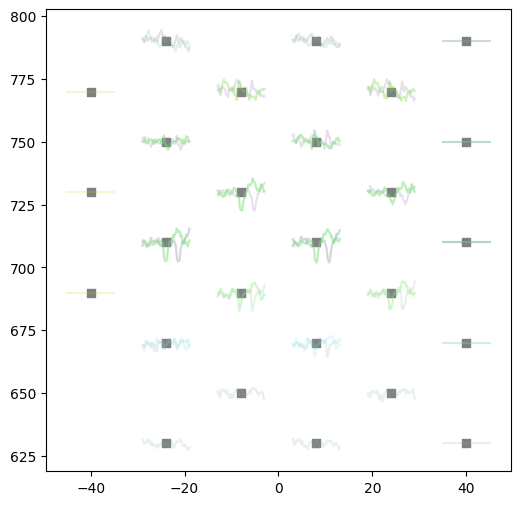

In [10]:
event_ids = [0, 7, 12, 15, 13]
waveform_len_to_plot = local_waveforms_tensor.shape[2]
waveform_start = 0
waveform_end = waveform_start + waveform_len_to_plot
waveform_x = np.linspace(-5.0, 5.0, waveform_len_to_plot)

colors = [np.random.rand(3) for _ in event_ids]

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

visited_channels = []

for i, event_id in enumerate(event_ids):
    for j in range(n_neighbors):
        channel_x = channel_locations_tensor[event_id,j,1] + center_locations_tensor[event_id,1]
        channel_y = channel_locations_tensor[event_id,j,2] + center_locations_tensor[event_id,2]
        if (channel_x, channel_y) not in visited_channels:
            ax.scatter(channel_x.cpu().numpy(), channel_y.cpu().numpy(), s=30, c="grey", marker='s')
            visited_channels.append((channel_x, channel_y))
        plt.plot(channel_x.cpu().numpy() + waveform_x, channel_y.cpu().numpy() + local_waveforms_tensor[event_id,j,waveform_start:waveform_end].cpu().numpy(), color=colors[i], alpha=0.2)

# Create spike dataset

In [11]:
local_waveforms_tensor = torch.concat((local_waveforms_tensor, amps_tensor[:,:,1].unsqueeze(-1)), axis=2)

exp_ids = torch.arange(n_events, device=device)
amps_argsorted = torch.argsort(amps_tensor, dim=1)
min_waveforms_tensor = local_waveforms_tensor[torch.arange(local_waveforms_tensor.shape[0]).unsqueeze(1), amps_argsorted[:,:,0], :][:,0,:-1]
min_amps_tensor = torch.min(min_waveforms_tensor, axis = 1, keepdim = True).values

training_set = SpikeDataset(amps_tensor, local_waveforms_tensor, channel_locations_tensor, center_locations_tensor, spike_cluster_id_tensor, exp_ids, min_amps_tensor, min_waveforms_tensor)
train_loader = torch.utils.data.DataLoader(training_set, batch_size=batch_size, shuffle=True)

# Train model

In [12]:
learning_rate = 0.001
beta_one = 0.99
beta_two = 0.999
n_epochs = 20

waveform_dims_flattened = local_waveforms_tensor.shape[1] * local_waveforms_tensor.shape[2]
exp_params = torch.concat((torch.log(-min_amps_tensor * 2.0), torch.full_like(min_amps_tensor, -0.035)), dim=1).to(device)

model = SpikeLocalizationVAE(waveform_dims_flattened, exp_params, channel_locations_tensor, device = device)
loss_func = SpikeLocalizationLossFunc(prior_var = 80)

optimizer = torch.optim.Adam(list(model.parameters()) + [model.decoder.exps], lr=learning_rate, weight_decay=0,
                            betas=(beta_one, beta_two))

model.train()
train_losses = []

for i in range(n_epochs):
    train_loss = 0
    n_batches = 0
    for (amps, waveforms, ch_locs, center_locs, spike_ids, exp_ids, min_amps, min_waveforms) in train_loader:
        optimizer.zero_grad()
        recon_amps, xyz_mu, xyz_var = model(waveforms, exp_ids, training = True)
        loss = loss_func(recon_amps, amps, xyz_mu, xyz_var)
        loss.backward()
        train_loss += loss.item() / amps.shape[0]
        optimizer.step()
        n_batches += 1
    train_losses.append(train_loss / n_batches)
    print(f"Epoch: {i}, Train Loss: {train_losses[-1]:.4f}")

Epoch: 0, Train Loss: 2.7367
Epoch: 1, Train Loss: 1.8747
Epoch: 2, Train Loss: 1.5229
Epoch: 3, Train Loss: 1.3630
Epoch: 4, Train Loss: 1.2630
Epoch: 5, Train Loss: 1.1872
Epoch: 6, Train Loss: 1.1084
Epoch: 7, Train Loss: 1.0659
Epoch: 8, Train Loss: 1.0271
Epoch: 9, Train Loss: 0.9912
Epoch: 10, Train Loss: 0.9682
Epoch: 11, Train Loss: 0.9306
Epoch: 12, Train Loss: 0.9079
Epoch: 13, Train Loss: 0.8945
Epoch: 14, Train Loss: 0.8809
Epoch: 15, Train Loss: 0.8723
Epoch: 16, Train Loss: 0.8529
Epoch: 17, Train Loss: 0.8378
Epoch: 18, Train Loss: 0.8289
Epoch: 19, Train Loss: 0.8219


# Run inference

In [13]:
model.eval()

vae_spatial_locations = torch.zeros((n_events, 3), device = device)
center_locations = torch.zeros((n_events, 3), device = device)
spike_ids = torch.zeros(n_events, device = device)

for i, (amps, waveforms, ch_locs, center_locs_batch, spike_ids_batch, exp_ids, min_amps, min_waveforms) in enumerate(train_loader):
    xyz_mu, xyz_var = model.encoder(waveforms)
    vae_spatial_locations[i*batch_size:(i+1)*batch_size] = xyz_mu.detach() + center_locs_batch
    center_locations[i*batch_size:(i+1)*batch_size] = center_locs_batch
    spike_ids[i*batch_size:(i+1)*batch_size] = spike_ids_batch

(-200.0, 200.0)

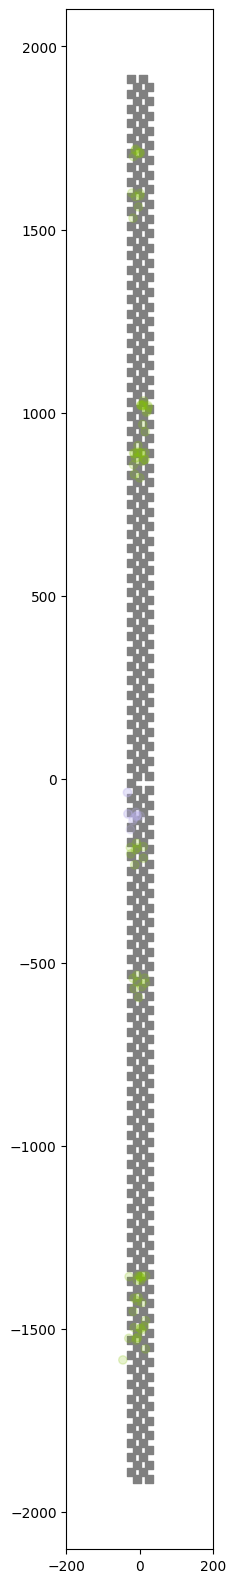

In [14]:
unique_sorted_ids = np.unique(spike_ids.cpu().numpy())
selected_cluster_ids = np.random.choice(unique_sorted_ids, size=2, replace=False)

plt.figure(figsize=(20,20))
plt.scatter(channel_positions[:,1].cpu().numpy(), channel_positions[:,2].cpu().numpy(), marker='s', color='grey')

colors = [np.random.rand(3) for _ in range(int(spike_ids.max().item()+1))]
scatter_colors = np.array([colors[int(i.item())] for i in spike_ids])

if selected_cluster_ids is None:
    plt.scatter(vae_spatial_locations.cpu().numpy()[:,1], vae_spatial_locations.cpu().numpy()[:,2], alpha=0.2, c=scatter_colors)
else:
    for cluster_id in selected_cluster_ids:
        id_mask = (spike_ids==cluster_id).cpu().numpy()
        if id_mask.sum() == 0:
            continue
        plt.scatter(vae_spatial_locations.cpu().numpy()[id_mask][:,1], vae_spatial_locations.cpu().numpy()[id_mask][:,2], alpha=0.2, c=scatter_colors[id_mask])

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim([-200, 200])

# Export model

In [16]:
test_waveform = local_waveforms_tensor[0].unsqueeze(0)

encoder = model.encoder
_ = encoder(test_waveform)
scripted_encoder = torch.jit.script(encoder)

torch.jit.save(scripted_encoder, "../models/spike_localization_encoder.pt")